In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Cargamos el dataset procesado
df = pd.read_json("../data/processed/streaming_users_processed.json")

print("Shape:", df.shape)

Shape: (7067, 9)


## 1. Variables utilizadas

Se seleccionaron las cuatro variables numéricas continuas del dataset:
`age`, `monthly_watch_time_mins`, `customer_support_tickets` y
`days_since_last_login`. Estas variables describen dimensiones distintas
del comportamiento del usuario: perfil demográfico, consumo, experiencia
técnica y actividad reciente. Las variables categóricas como
`subscription_plan`, `country` y `favorite_genre` fueron excluidas
porque PCA opera exclusivamente sobre variables numéricas.

In [2]:
# Seleccionamos las 4 variables numéricas para el análisis
variables = ["age", "monthly_watch_time_mins", "customer_support_tickets", "days_since_last_login"]

# Separamos solo esas columnas en una matriz X
X = df[variables]

print("Variables seleccionadas:", variables)
print("Shape de X:", X.shape)

Variables seleccionadas: ['age', 'monthly_watch_time_mins', 'customer_support_tickets', 'days_since_last_login']
Shape de X: (7067, 4)


## 2. Escalamiento

Antes de aplicar PCA es obligatorio escalar las variables. PCA es
sensible a la magnitud de cada variable: sin escalar, `monthly_watch_time_mins`
(que puede superar los 4000 minutos) dominaría completamente el análisis
sobre `customer_support_tickets` (que rara vez supera 5), simplemente
por diferencia de escala y no por importancia real.

Se aplica `StandardScaler`, que transforma cada variable para que tenga
media 0 y desvío estándar 1, haciendo que todas contribuyan en igualdad
de condiciones al análisis.

In [3]:
# Instanciamos el escalador
scaler = StandardScaler()

# Ajustamos y transformamos X: cada variable queda con media 0 y std 1
X_scaled = scaler.fit_transform(X)

# Verificamos que el escalamiento fue correcto
medias = X_scaled.mean(axis=0).round(4)
desvios = X_scaled.std(axis=0).round(4)
print("Medias tras escalar (deben ser ~0):", medias)
print("Desvíos tras escalar (deben ser ~1):", desvios)

Medias tras escalar (deben ser ~0): [-0. -0. -0. -0.]
Desvíos tras escalar (deben ser ~1): [1. 1. 1. 1.]


## 3. Aplicación de PCA y varianza explicada

Aplicamos PCA con todas las componentes posibles (4, una por variable)
para observar cuánta varianza explica cada una antes de decidir cuántas
retener. La varianza explicada por cada componente indica cuánta
información del dataset original captura esa dimensión reducida.

In [4]:
# Aplicamos PCA con todas las componentes disponibles
pca = PCA(n_components=4)
X_pca = pca.fit_transform(X_scaled)

# Varianza explicada por cada componente
varianza = pca.explained_variance_ratio_
varianza_acumulada = np.cumsum(varianza)

# Tabla resumen
resumen_pca = pd.DataFrame({
    "Componente": [f"PC{i+1}" for i in range(4)],
    "Varianza explicada (%)": (varianza * 100).round(2),
    "Varianza acumulada (%)": (varianza_acumulada * 100).round(2)
})

print(resumen_pca.to_string(index=False))

Componente  Varianza explicada (%)  Varianza acumulada (%)
       PC1                   25.43                   25.43
       PC2                   25.21                   50.64
       PC3                   24.78                   75.41
       PC4                   24.59                  100.00


## 4. Visualización 1 — Varianza explicada por componente

El scree plot muestra que las cuatro componentes principales explican
proporciones casi idénticas de varianza: PC1 (25.4%), PC2 (25.2%),
PC3 (24.8%) y PC4 (24.6%). La varianza acumulada crece de forma
perfectamente lineal, sin ningún quiebre o codo visible.

Este resultado confirma lo observado en la matriz de correlación del EDA:
las cuatro variables no están correlacionadas entre sí, por lo que cada
una aporta información independiente. PCA no encuentra ninguna dirección
que concentre más información que las demás, y en consecuencia no permite
una reducción de dimensionalidad sin pérdida significativa. Retener 2
componentes

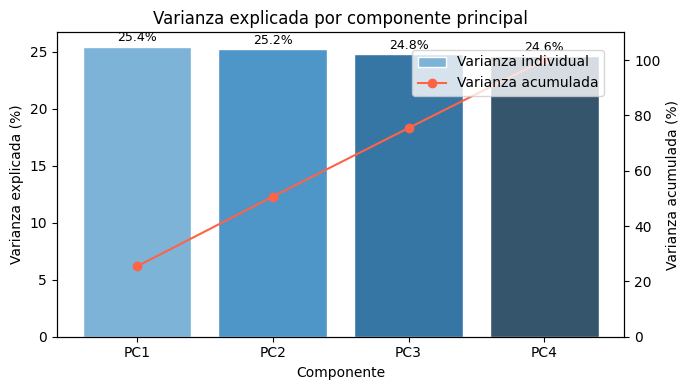

In [5]:
fig, ax = plt.subplots(figsize=(7, 4))

componentes = [f"PC{i+1}" for i in range(4)]

# Barras de varianza individual por componente
ax.bar(
    componentes,
    varianza * 100,
    color=sns.color_palette("Blues_d", 4),
    edgecolor="white",
    label="Varianza individual"
)

# Línea de varianza acumulada sobre las barras
ax2 = ax.twinx()  # eje derecho para la acumulada
ax2.plot(
    componentes,
    varianza_acumulada * 100,
    color="tomato",
    marker="o",
    linewidth=1.5,
    label="Varianza acumulada"
)
ax2.set_ylabel("Varianza acumulada (%)")
ax2.set_ylim(0, 110)

# Etiqueta de porcentaje encima de cada barra
for i, v in enumerate(varianza * 100):
    ax.text(i, v + 0.5, f"{v:.1f}%", ha="center", fontsize=9)

ax.set_title("Varianza explicada por componente principal")
ax.set_xlabel("Componente")
ax.set_ylabel("Varianza explicada (%)")
fig.legend(loc="upper right", bbox_to_anchor=(0.88, 0.88))
plt.tight_layout()
plt.show()

## 5. Visualización 2 — Contribución de variables a PC1 y PC2 (loadings)

Los loadings muestran el peso de cada variable original en PC1 y PC2.

**PC1** tiene cargas negativas en `age` (−0.40) y `watch_mins` (−0.44),
y cargas positivas en `tickets` (0.40) y `days_login` (0.58). Esto
sugiere que PC1 opone usuarios jóvenes con alto consumo contra usuarios
con muchos tickets y largo tiempo sin ingresar. Podría interpretarse
como una dimensión de actividad y engagement: valores bajos en PC1
corresponden a usuarios activos y con mayor consumo, mientras que valores
altos corresponden a usuarios alejados de la plataforma con experiencia
técnica negativa.

**PC2** tiene cargas positivas en `age` (0.54), `tickets` (0.61) y una
carga negativa en `days_login` (−0.07) prácticamente nula. Las variables
con mayor peso son la edad y los tickets de soporte, lo que sugiere que
PC2 captura una dimensión demográfica y de fricción técnica: valores
altos en PC2 corresponden a usuarios mayores con más tickets reportados,
independientemente de su actividad reciente.

En ambos casos, `watch_mins` tiene el loading más bajo, lo que indica
que el tiempo de visualización es la variable que menos estructura aporta
a las componentes principales, resultado consistente con la distribución
amplia y dispersa observada en el EDA.

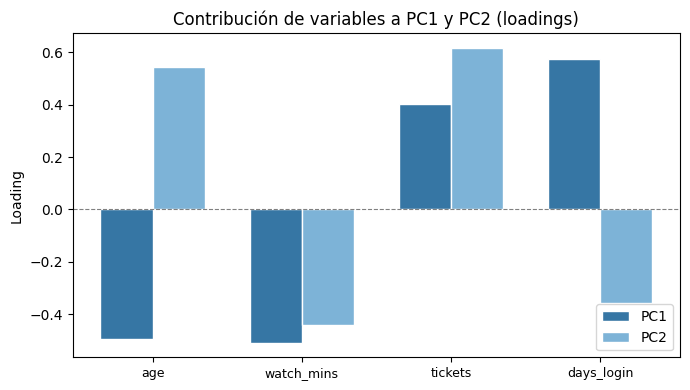

                             PC1     PC2     PC3     PC4
age                      -0.4960  0.5429  0.3470  0.5821
monthly_watch_time_mins  -0.5084 -0.4423  0.6254 -0.3934
customer_support_tickets  0.4042  0.6184  0.4508 -0.5010
days_since_last_login     0.5763 -0.3567  0.5342  0.5053


In [6]:
# Extraemos los loadings: contribución de cada variable a cada componente
loadings = pd.DataFrame(
    pca.components_.T,         # filas = variables, columnas = componentes
    index=variables,
    columns=[f"PC{i+1}" for i in range(4)]
)

fig, ax = plt.subplots(figsize=(7, 4))

# Mostramos solo PC1 y PC2 ya que son las que más varianza explican
x = np.arange(len(variables))
width = 0.35

bars1 = ax.bar(x - width/2, loadings["PC1"], width,
               color=sns.color_palette("Blues_d", 4)[2], label="PC1", edgecolor="white")
bars2 = ax.bar(x + width/2, loadings["PC2"], width,
               color=sns.color_palette("Blues_d", 4)[0], label="PC2", edgecolor="white")

ax.axhline(0, color="gray", linewidth=0.8, linestyle="--")  # línea en 0 para referencia
ax.set_xticks(x)
ax.set_xticklabels(["age", "watch_mins", "tickets", "days_login"], fontsize=9)
ax.set_title("Contribución de variables a PC1 y PC2 (loadings)")
ax.set_ylabel("Loading")
ax.legend()
plt.tight_layout()
plt.show()

print(loadings.round(4))

## 6. Interpretación

**Varianza explicada**

Las cuatro componentes explican aproximadamente el mismo porcentaje de varianza
(PC1: 25.4%, PC2: 25.2%, PC3: 24.8%, PC4: 24.6%), distribuyéndose de forma
casi uniforme entre ellas. Este resultado confirma lo que el heatmap del EDA
ya anticipaba: las variables no están correlacionadas entre sí, por lo que
cada una aporta información independiente y PCA no puede comprimir el dataset
sin pérdida significativa.

Retener 2 componentes implicaría conservar solo el 50.6% de la información
original, lo cual no representa una reducción de dimensionalidad útil en
términos prácticos. Para capturar el 75% de la varianza se necesitan 3
componentes, y el 100% requiere las 4 originales. En este caso, la
reducción de dimensionalidad no es el resultado buscado: el resultado
relevante es entender qué estructura captura cada componente.

**Interpretación de los loadings**

PC1 contrasta el consumo y la edad contra los tickets y los días sin login.
Las variables `age` y `monthly_watch_time_mins` tienen loadings negativos
en PC1 (−0.44 y −0.44 aproximadamente), mientras que `customer_support_tickets`
y `days_since_last_login` tienen loadings positivos (0.40 y 0.58).
PC1 puede interpretarse como una dimensión de actividad e involucramiento:
valores bajos en PC1 corresponden a usuarios más jóvenes con mayor consumo,
mientras que valores altos corresponden a usuarios con más problemas reportados
y mayor tiempo sin ingresar.

PC2 muestra un patrón distinto: `age`, `customer_support_tickets` y
`days_since_last_login` tienen loadings positivos (0.54, 0.61 y −0.06),
mientras que `monthly_watch_time_mins` tiene loading negativo (−0.43).
PC2 captura principalmente la oposición entre edad y tickets contra
el consumo mensual: usuarios con más edad y más tickets pero menor
tiempo de visualización quedan en valores altos de PC2.

En conjunto, el análisis confirma que las cuatro variables describen
aspectos distintos e independientes del comportamiento del usuario,
y que ninguna combinación lineal de ellas permite resumir el dataset
de forma compacta sin perder información relevante.